fit slope a = 6.3323418701e-03, theory a_th = 6.3325739776e-03, frac = -3.665e-05
fit range: Lambda/m >= 50  (N_fit = 42)


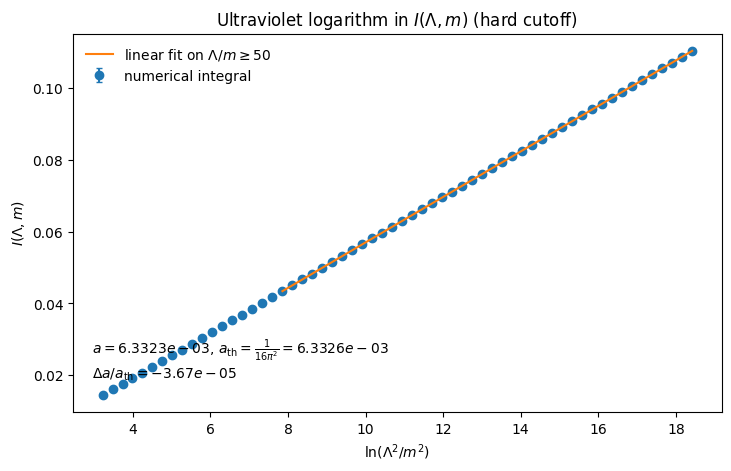

Residual fit (high-Lambda): Delta ≈ c0 + c1*(1/Lambda^2)
c0 = -6.3325739439e-03, c1 = 1.2662243768e-02


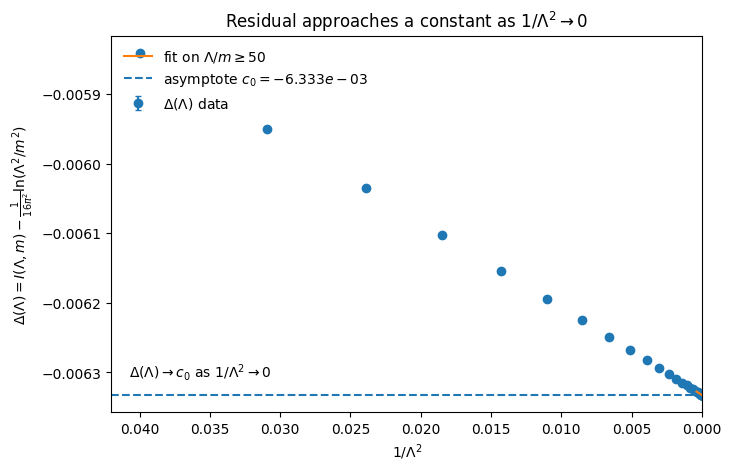

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from pathlib import Path
from scipy.integrate import quad
m = 1.0
Lmin, Lmax, N = 5.0*m, 1e4*m, 60
fit_Lmin = 50.0*m
epsabs, epsrel = 1e-12, 1e-12
out_dir = Path("figures")
dpi_png = 400

def I_1d(L, m=1.0):
    """I(L,m) = (1/8π^2) ∫_0^L k^3/(k^2+m^2)^2 dk"""
    integrand = lambda k: (k**3) / (k**2 + m**2)**2
    val, err = quad(integrand, 0.0, L, epsabs=epsabs, epsrel=epsrel, limit=400)
    return val / (8.0 * pi**2), err / (8.0 * pi**2)
Ls = np.geomspace(Lmin, Lmax, N)
ys = np.empty_like(Ls)
yerr = np.empty_like(Ls)
for i, L in enumerate(Ls):
    ys[i], yerr[i] = I_1d(L, m=m)

x = np.log((Ls**2) / (m**2))  # x = ln(Lambda^2/m^2)
mask = Ls >= fit_Lmin

# Fit for Fig 1: y = a x + b (high-L subset)
a, b = np.polyfit(x[mask], ys[mask], 1)
a_th = 1.0 / (16.0 * pi**2)
frac = (a - a_th) / a_th

print(f"fit slope a = {a:.10e}, theory a_th = {a_th:.10e}, frac = {frac:.3e}")
print(f"fit range: Lambda/m >= {fit_Lmin/m:g}  (N_fit = {mask.sum()})")

out_dir.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)

ax.errorbar(
    x, ys, yerr=yerr, fmt="o", capsize=2,
    label="numerical integral", zorder=2
)

xx = np.linspace(x[mask].min(), x[mask].max(), 400)
ax.plot(
    xx, a*xx + b,
    label=rf"linear fit on $\Lambda/m \geq {fit_Lmin/m:g}$",
    zorder=3
)

ax.set_xlabel(r"$\ln(\Lambda^2/m^2)$")
ax.set_ylabel(r"$I(\Lambda,m)$")
ax.set_title(r"Ultraviolet logarithm in $I(\Lambda,m)$ (hard cutoff)")
ax.legend(frameon=False, loc="upper left")

x_annot = x.min() + 0.6*(x.max()-x.min())*0.0  # keep left-ish
y_annot = ys.min() + 0.08*(ys.max()-ys.min())  # slightly above bottom
ax.text(
    0.03, 0.08,
    rf"$a={a:.4e}$, $a_{{\rm th}}=\frac{{1}}{{16\pi^2}}={a_th:.4e}$" "\n"
    rf"$\Delta a/a_{{\rm th}}={frac:.2e}$",
    transform=ax.transAxes,
    va="bottom", ha="left"
)

fig.savefig(out_dir / "Fig1_I_vs_logLambda2.pdf")
fig.savefig(out_dir / "Fig1_I_vs_logLambda2.png", dpi=dpi_png)
plt.show()
plt.close(fig)

Delta = ys - a_th * x
invL2 = 1.0 / (Ls**2)

# Fit Delta ≈ c0 + c1*(1/L^2) on high-L subset
c1, c0 = np.polyfit(invL2[mask], Delta[mask], 1)
print("Residual fit (high-Lambda): Delta ≈ c0 + c1*(1/Lambda^2)")
print(f"c0 = {c0:.10e}, c1 = {c1:.10e}")

fig, ax = plt.subplots(figsize=(7.2, 4.6), constrained_layout=True)

ax.errorbar(
    invL2, Delta, yerr=yerr, fmt="o", capsize=2,
    label=r"$\Delta(\Lambda)$ data", zorder=2
)

xx2 = np.linspace(invL2[mask].min(), invL2[mask].max(), 400)
ax.plot(
    xx2, c1*xx2 + c0,
    label=rf"fit on $\Lambda/m \geq {fit_Lmin/m:g}$",
    zorder=3
)

# Add horizontal asymptote line at c0
ax.axhline(c0, linestyle="--", linewidth=1.5, label=rf"asymptote $c_0={c0:.3e}$", zorder=1)

ax.set_xlabel(r"$1/\Lambda^2$")
ax.set_ylabel(r"$\Delta(\Lambda)=I(\Lambda,m)-\frac{1}{16\pi^2}\ln(\Lambda^2/m^2)$")
ax.set_title(r"Residual approaches a constant as $1/\Lambda^2 \to 0$")
ax.legend(frameon=False, loc="upper left")

ax.set_xlim(invL2.max()*1.05, 0.0)

ax.text(
    0.03, 0.08,
    rf"$\Delta(\Lambda)\to c_0$ as $1/\Lambda^2\to 0$",
    transform=ax.transAxes,
    va="bottom", ha="left"
)

fig.savefig(out_dir / "Fig2_Delta_vs_invLambda2.pdf")
fig.savefig(out_dir / "Fig2_Delta_vs_invLambda2.png", dpi=dpi_png)
plt.show()
plt.close(fig)

In [2]:
import numpy as np
from math import pi
from scipy.integrate import quad

m = 1.0
Lmin, Lmax, N = 5.0*m, 1e4*m, 60
epsabs, epsrel = 1e-12, 1e-12

def I_1d(L, m=1.0):
    integrand = lambda k: (k**3) / (k**2 + m**2)**2
    val, err = quad(integrand, 0.0, L, epsabs=epsabs, epsrel=epsrel, limit=400)
    return val / (8.0 * pi**2)

Ls = np.geomspace(Lmin, Lmax, N)
ys = np.array([I_1d(L, m=m) for L in Ls])
x = np.log((Ls**2)/(m**2))

a_th = 1.0/(16.0*pi**2)

for fit_Lmin in [30.0*m, 50.0*m, 100.0*m]:
    mask = Ls >= fit_Lmin
    a, b = np.polyfit(x[mask], ys[mask], 1)
    frac = (a - a_th)/a_th
    print(f"fit_Lmin={fit_Lmin/m:>5.0f}: a={a:.10e}, frac={(frac):+.3e}, N_fit={mask.sum()}")

fit_Lmin=   30: a=6.3320211171e-03, frac=-8.730e-05, N_fit=46
fit_Lmin=   50: a=6.3323418701e-03, frac=-3.665e-05, N_fit=42
fit_Lmin=  100: a=6.3325091822e-03, frac=-1.023e-05, N_fit=36
